# EDA 03 - Train Moments

**Data source**: `train-moments` Azure Blob Storage container  
**Loaded by**: `src/data_loader.load_train_moment_files()` + `parse_train_moments()`  
**Output**: `data/processed/train_moments_clean.parquet`

This notebook explores the raw train movement records before any spatial join with road closures. Train moments capture real-time observations of trains at locations: arrivals, departures, and passing events with both planned and actual timestamps. Understanding this source independently reveals the baseline operational characteristics of rail services, data quality, and the natural delay distribution before any road-closure conditioning.

---
**Sections**
1. Load and inspect raw data  
2. Missing value audit  
3. Event type and variation status distributions  
4. Raw delay (timetable_variation) distribution  
5. Temporal distribution of movements  
6. Station code coverage (STANOX match rate)  
7. Operational flags (is_delayed, delay_monitoring_point, train_terminated)  
8. Platform, route and direction distributions  
9. Save cleaned output  


## 0. Setup

In [27]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "..")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 40)
os.makedirs("figures/eda_03", exist_ok=True)
os.makedirs("./data/processed", exist_ok=True)
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load and Inspect Raw Data

In [28]:
from datetime import datetime, timezone
from src.data_loader import load_train_moment_files, parse_train_moments

START = datetime(2026, 4, 10, 0, 0, 0, tzinfo=timezone.utc)
END   = datetime(2026, 4, 28, 23, 59, 59, tzinfo=timezone.utc)

# Load stations_reference.parquet for station code mapping
stations_reference_df = pd.read_parquet(
    "./data/processed/stations_reference.parquet",
    engine="pyarrow"
)

train_files = load_train_moment_files(START, END)
print(f"Files retrieved: {len(train_files)}")

raw_df = parse_train_moments(train_files, stations_reference_df)
print(f"Raw shape: {raw_df.shape}")
print(f"Columns: {list(raw_df.columns)}")

Using 2596 local files within the time window.
Files retrieved: 2596
Skipping empty CSV file: data\train\train_data_20260426_151255.csv
Raw shape: (296940, 20)
Columns: ['train_id', 'actual_timestamp', 'planned_timestamp', 'gbtt_timestamp', 'loc_stanox', 'next_stanox', 'event_type', 'planned_event_type', 'variation_status', 'timetable_variation', 'platform', 'route', 'direction', 'train_terminated', 'delay_monitoring_point', 'msg_timestamp', 'data_source', 'is_delayed', 'station_code', 'station_name']


## Data Types and Basic Statistics

In [29]:
raw_df.head()

,train_id,actual_timestamp,planned_timestamp,gbtt_timestamp,loc_stanox,next_stanox,event_type,planned_event_type,variation_status,timetable_variation,platform,route,direction,train_terminated,delay_monitoring_point,msg_timestamp,data_source,is_delayed,station_code,station_name
0,015H562C10,2026-04-10 08:15:00,2026-04-10 08:20:30,2026-04-10 08:20:00,1008.0,NaN,DEPARTURE,DEPARTURE,EARLY,5.0,NaN,NaN,NaN,True,True,1775810813000,SDR,0,GGJ,Georgemas Junction
1,512O17MF10,2026-04-10 09:47:00,2026-04-10 09:47:30,2026-04-10 09:48:00,51717.0,51720.0,ARRIVAL,ARRIVAL,ON TIME,0.0,1,0.0,UP,False,False,1775810813000,SMART,0,RYH,Rye House
2,522S14ME10,2026-04-10 09:46:00,2026-04-10 09:46:00,NaT,51914.0,51913.0,DEPARTURE,DEPARTURE,ON TIME,0.0,2,1.0,DOWN,False,True,1775810814000,SMART,0,BMD,Brimsdown
3,525E20MF10,2026-04-10 09:47:00,NaT,NaT,52705.0,NaN,ARRIVAL,ARRIVAL,OFF ROUTE,0.0,NaN,NaN,NaN,False,False,1775810814000,SMART,0,LHS,Limehouse
4,522T37MF10,2026-04-10 09:47:00,2026-04-10 09:46:30,2026-04-10 09:47:00,52729.0,52733.0,ARRIVAL,ARRIVAL,LATE,1.0,1,0.0,UP,False,False,1775810814000,SMART,1,WST,Wood Street


In [30]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 296940 entries, 0 to 296939
Data columns (total 20 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   train_id                296940 non-null  str           
 1   actual_timestamp        284222 non-null  datetime64[ms]
 2   planned_timestamp       280818 non-null  datetime64[ms]
 3   gbtt_timestamp          188991 non-null  datetime64[ms]
 4   loc_stanox              285342 non-null  float64       
 5   next_stanox             269153 non-null  float64       
 6   event_type              284222 non-null  str           
 7   planned_event_type      284222 non-null  str           
 8   variation_status        284222 non-null  str           
 9   timetable_variation     284222 non-null  float64       
 10  platform                182269 non-null  object        
 11  route                   267416 non-null  object        
 12  direction               243174 non-null  

In [31]:
raw_df.describe().round(2)

,actual_timestamp,planned_timestamp,gbtt_timestamp,loc_stanox,next_stanox,timetable_variation,msg_timestamp,is_delayed
count,284222,280818,188991,285342.00,269153.00,284222.00,2.969400e+05,296940.00
mean,2026-04-20 12:11:07.580000,2026-04-20 12:11:43.829000,2026-04-20 11:45:33.313000,57802.38,57765.18,2.61,1.776683e+12,0.40
min,2026-04-03 23:44:00,2026-04-03 23:56:00,2026-04-03 23:56:00,713.00,750.00,0.00,1.775811e+12,0.00
25%,2026-04-15 08:41:00,2026-04-15 08:39:30,2026-04-15 08:36:00,36184.00,36175.00,0.00,1.776239e+12,0.00
50%,2026-04-21 06:53:00,2026-04-21 06:53:30,2026-04-21 06:37:00,64604.00,64313.00,1.00,1.776750e+12,0.00
75%,2026-04-26 13:05:00,2026-04-26 13:04:30,2026-04-26 13:01:00,86451.00,86461.00,2.00,1.777205e+12,1.00
max,2026-04-28 17:46:00,2026-04-28 17:51:00,2026-04-28 17:47:00,89745.00,89743.00,499.00,1.777394e+12,1.00
std,NaN,NaN,NaN,27679.74,27677.33,7.61,5.077460e+08,0.49


## 2. Missing Value Audit

The two most critical fields for the main analysis are `actual_timestamp` and `planned_timestamp`. Missing values in these fields prevent delay computation and cause rows to be dropped by the filtering pipeline.

In [32]:
missing = pd.DataFrame({
    "missing_count": raw_df.isna().sum(),
    "missing_pct": (raw_df.isna().sum() / len(raw_df) * 100).round(2)
}).sort_values("missing_pct", ascending=False)

print(missing.to_string())

# Critical field breakdown — these two fields gate all delay computation
print()
for col in ["actual_timestamp", "planned_timestamp"]:
    n = raw_df[col].isna().sum()
    print(f"{col} missing: {n:,} ({n/len(raw_df)*100:.1f}%)")

both_missing   = (raw_df["actual_timestamp"].isna() & raw_df["planned_timestamp"].isna()).sum()
either_missing = (raw_df["actual_timestamp"].isna() | raw_df["planned_timestamp"].isna()).sum()
print(f"Both missing:   {both_missing:,}")
print(f"Either missing: {either_missing:,}")

                        missing_count  missing_pct
platform                       114671        38.62
gbtt_timestamp                 107949        36.35
station_code                    80107        26.98
station_name                    80107        26.98
direction                       53766        18.11
route                           29524         9.94
next_stanox                     27787         9.36
planned_timestamp               16122         5.43
delay_monitoring_point          12718         4.28
actual_timestamp                12718         4.28
timetable_variation             12718         4.28
event_type                      12718         4.28
planned_event_type              12718         4.28
variation_status                12718         4.28
train_terminated                12718         4.28
loc_stanox                      11598         3.91
data_source                       341         0.11
train_id                            0         0.00
msg_timestamp                  

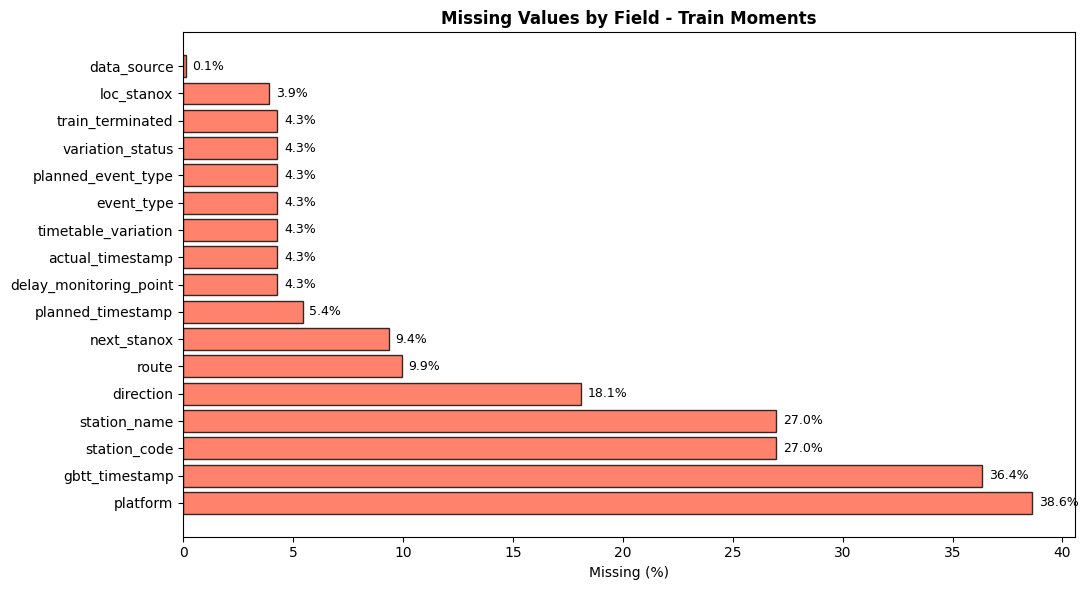

In [33]:
fig, ax = plt.subplots(figsize=(11, 6))
missing_nonzero = missing[missing["missing_pct"] > 0]
if len(missing_nonzero) > 0:
    ax.barh(missing_nonzero.index, missing_nonzero["missing_pct"],
            color="tomato", edgecolor="black", alpha=0.8)
    ax.set_xlabel("Missing (%)")
    ax.set_title("Missing Values by Field - Train Moments", fontweight="bold")
    for i, v in enumerate(missing_nonzero["missing_pct"]):
        ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)
else:
    ax.text(0.5, 0.5, "No missing values", ha="center", va="center",
            transform=ax.transAxes, fontsize=14)
plt.tight_layout()
plt.savefig("figures/eda_03/missing_values.png", dpi=200, bbox_inches="tight")
plt.show()

## Drop Missing Timestamps and Station Names

In [34]:
# Step 1: drop rows where either timestamp is null - delay cannot be computed
before = len(raw_df)
clean_df = raw_df.dropna(subset=["actual_timestamp", "planned_timestamp"])
print(f"Dropped {before - len(clean_df):,} rows (timestamps null)")

# Step 2: drop rows missing station name - cannot be spatially matched
before = len(clean_df)
clean_df = clean_df.dropna(subset=["station_name"])
print(f"Dropped {before - len(clean_df):,} rows (station name null)")
print(f"Clean dataset: {len(clean_df):,} rows")


clean_df["platform"] = clean_df["platform"].astype("string")
clean_df["route"]    = clean_df["route"].astype("string")
clean_df["planned_date"] = clean_df["planned_timestamp"].dt.date
clean_df["actual_date"]  = clean_df["actual_timestamp"].dt.date

Dropped 16,122 rows (timestamps null)
Dropped 67,934 rows (station name null)
Clean dataset: 212,884 rows


##  Compute Delay Features

In [35]:
# Core delay metric: actual - planned in minutes
# Negative = early, positive = late
clean_df["delay_minutes"] = (
    clean_df["actual_timestamp"] - clean_df["planned_timestamp"]
).dt.total_seconds() / 60

# Directional split
clean_df["late_minutes"]  = clean_df["delay_minutes"].clip(lower=0)
clean_df["early_minutes"] = (-clean_df["delay_minutes"]).clip(lower=0)

# Binary flags
clean_df["is_late"]                   = (clean_df["delay_minutes"] > 0).astype(int)
clean_df["is_early"]                  = (clean_df["delay_minutes"] < 0).astype(int)
clean_df["is_delayed_5min"]           = (clean_df["delay_minutes"] > 5).astype(int)
clean_df["is_severely_delayed_15min"] = (clean_df["delay_minutes"] > 15).astype(int)

# Temporal features used in modelling
clean_df["actual_hour"] = clean_df["actual_timestamp"].dt.hour
clean_df["actual_dow"]  = clean_df["actual_timestamp"].dt.dayofweek
clean_df["is_peak"]     = clean_df["actual_hour"].isin(
    list(range(7, 10)) + list(range(17, 20))
).astype(int)

print("Delay statistics (minutes):")
print(clean_df["delay_minutes"].describe().round(2))
print(f"\nLate movements:           {clean_df['is_late'].sum():,} ({clean_df['is_late'].mean()*100:.1f}%)")
print(f"Early movements:          {clean_df['is_early'].sum():,} ({clean_df['is_early'].mean()*100:.1f}%)")
print(f"Delayed > 5 min:          {clean_df['is_delayed_5min'].sum():,} ({clean_df['is_delayed_5min'].mean()*100:.1f}%)")
print(f"Severely delayed > 15min: {clean_df['is_severely_delayed_15min'].sum():,} ({clean_df['is_severely_delayed_15min'].mean()*100:.1f}%)")

Delay statistics (minutes):
count    212884.00
mean          1.05
std           6.83
min        -295.00
25%          -0.50
50%           0.00
75%           1.50
max         457.50
Name: delay_minutes, dtype: float64

Late movements:           88,887 (41.8%)
Early movements:          82,811 (38.9%)
Delayed > 5 min:          16,546 (7.8%)
Severely delayed > 15min: 4,133 (1.9%)


## Delay Distribution

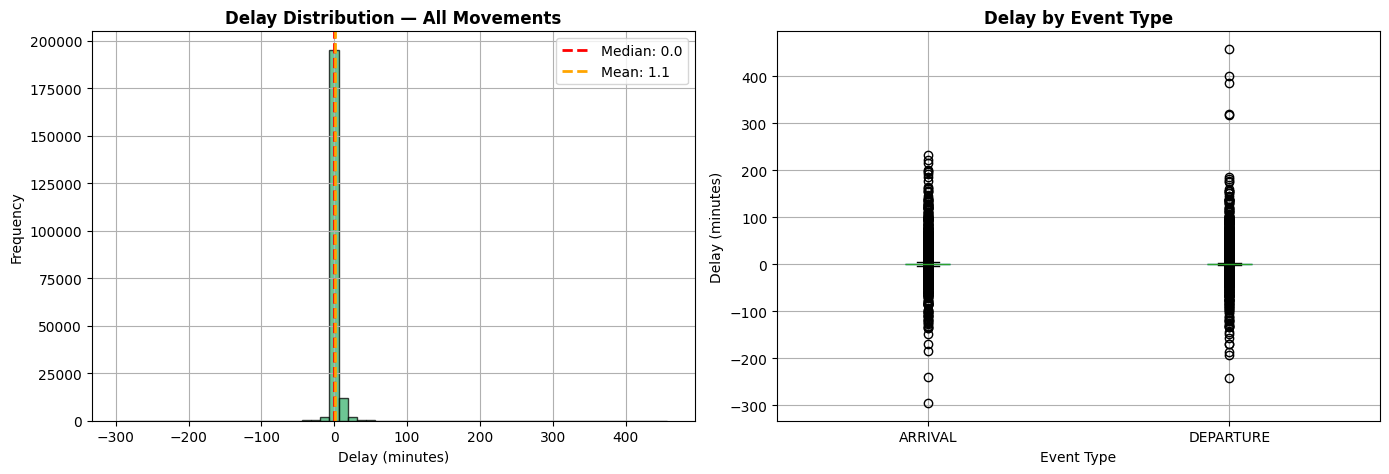


Quantiles:
0.01    -8.0
0.05    -2.0
0.25    -0.5
0.50     0.0
0.75     1.5
0.95     7.5
0.99    22.5
Name: delay_minutes, dtype: float64

Skewness: 7.215   Kurtosis: 422.170


In [36]:
delay = clean_df["delay_minutes"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

delay.hist(bins=60, ax=axes[0], edgecolor="black", alpha=0.75, color="mediumseagreen")
axes[0].axvline(delay.median(), color="red",    linestyle="--", lw=2,
                label=f"Median: {delay.median():.1f}")
axes[0].axvline(delay.mean(),   color="orange", linestyle="--", lw=2,
                label=f"Mean: {delay.mean():.1f}")
axes[0].set_xlabel("Delay (minutes)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Delay Distribution — All Movements", fontweight="bold")
axes[0].legend()

clean_df.boxplot(column="delay_minutes", by="event_type", ax=axes[1], patch_artist=True)
axes[1].set_title("Delay by Event Type", fontweight="bold")
axes[1].set_xlabel("Event Type")
axes[1].set_ylabel("Delay (minutes)")
plt.suptitle("")

plt.tight_layout()
plt.savefig("figures/eda_03/delay_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

print("\nQuantiles:")
print(delay.quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(2))
print(f"\nSkewness: {delay.skew():.3f}   Kurtosis: {delay.kurtosis():.3f}")

In [37]:
# winsorise at 1st and 99th percentile before aggregation
# Prevents single extreme trains from skewing station-day means
P01 = clean_df["delay_minutes"].quantile(0.01)
P99 = clean_df["delay_minutes"].quantile(0.99)
clean_df["delay_minutes"] = clean_df["delay_minutes"].clip(lower=P01, upper=P99)

print(f"winsorised to [{P01:.1f}, {P99:.1f}] minutes")
print(f"Skewness after: {clean_df['delay_minutes'].skew():.3f}")

winsorised to [-8.0, 22.5] minutes
Skewness after: 3.018


## Delay by Peak vs Off-Peak

Delay by peak vs off-peak:


,count,mean,median,std
is_peak,,,,
Off-peak,131130,0.942,0.0,3.989
"Peak (07-09, 17-19)",81754,1.099,0.0,3.641


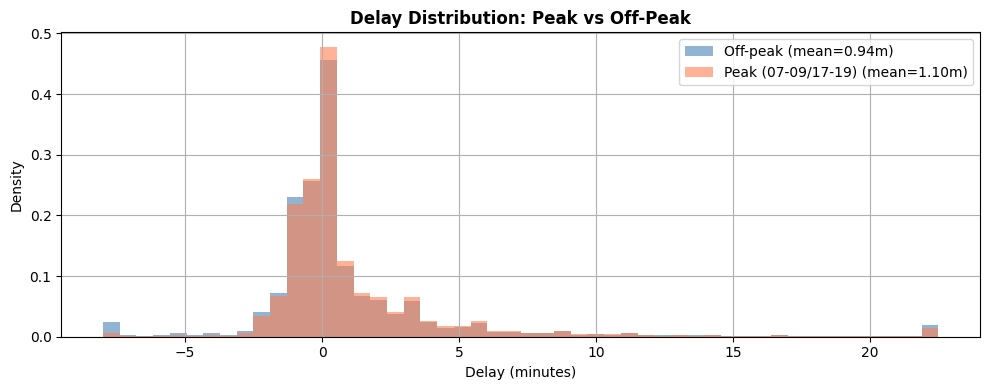

In [38]:
peak_summary = (
    clean_df
    .groupby("is_peak")["delay_minutes"]
    .agg(["count", "mean", "median", "std"])
    .round(3)
    .rename(index={0: "Off-peak", 1: "Peak (07-09, 17-19)"})
)
print("Delay by peak vs off-peak:")
display(peak_summary)

fig, ax = plt.subplots(figsize=(10, 4))
for label, grp, color in [
    ("Off-peak",          clean_df[clean_df["is_peak"] == 0]["delay_minutes"], "steelblue"),
    ("Peak (07-09/17-19)", clean_df[clean_df["is_peak"] == 1]["delay_minutes"], "coral"),
]:
    grp.hist(bins=50, ax=ax, alpha=0.6, color=color,
             label=f"{label} (mean={grp.mean():.2f}m)", density=True)

ax.set_xlabel("Delay (minutes)")
ax.set_ylabel("Density")
ax.set_title("Delay Distribution: Peak vs Off-Peak", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("figures/eda_03/delay_peak_vs_offpeak.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. Event Type and Variation Status

In [39]:
et = clean_df["event_type"].value_counts()
vs = clean_df["variation_status"].value_counts()

print("=== Event Type ===")
print(et.to_string())
print()
print("=== Variation Status ===")
print(vs.to_string())
print()
print("=== Cross-tabulation: Event Type × Variation Status ===")
print(pd.crosstab(clean_df["event_type"], clean_df["variation_status"],
                  margins=True).to_string())

=== Event Type ===
event_type
DEPARTURE    108495
ARRIVAL      104389

=== Variation Status ===
variation_status
LATE       88887
ON TIME    74749
EARLY      49248

=== Cross-tabulation: Event Type × Variation Status ===
variation_status  EARLY   LATE  ON TIME     All
event_type                                     
ARRIVAL           24446  45304    34639  104389
DEPARTURE         24802  43583    40110  108495
All               49248  88887    74749  212884


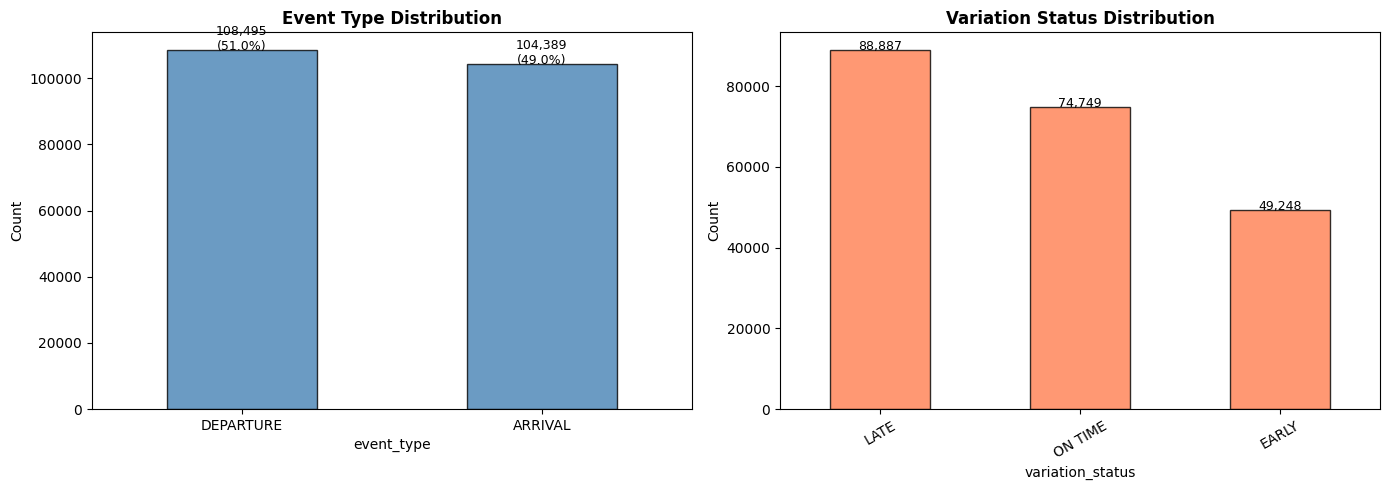

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

et.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black", alpha=0.8)
axes[0].set_title("Event Type Distribution", fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(et.values):
    axes[0].text(i, v + 50, f"{v:,}\n({v/len(clean_df)*100:.1f}%)",
                 ha="center", fontsize=9)

vs.plot(kind="bar", ax=axes[1], color="coral", edgecolor="black", alpha=0.8)
axes[1].set_title("Variation Status Distribution", fontweight="bold")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=30)
for i, v in enumerate(vs.values):
    axes[1].text(i, v + 50, f"{v:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("figures/eda_03/event_variation.png", dpi=200, bbox_inches="tight")
plt.show()

## Temporal Distribution of Movements

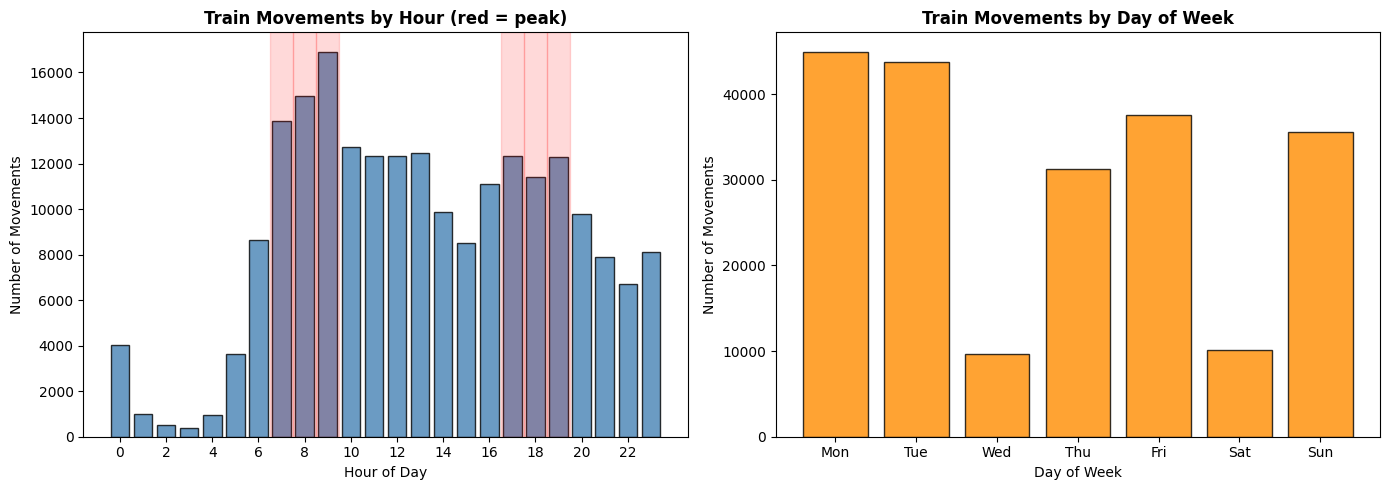

Movements by date:
actual_date
2026-04-03        1
2026-04-08        1
2026-04-09       42
2026-04-10    17770
2026-04-11     3504
2026-04-12     8244
2026-04-13    15262
2026-04-14     5316
2026-04-15     9608
2026-04-16    11284
2026-04-17     6999
2026-04-18     5269
2026-04-19    11869
2026-04-20     8593
2026-04-21    18331
2026-04-22        6
2026-04-23    19938
2026-04-24    12808
2026-04-25     1318
2026-04-26    15515
2026-04-27    21128
2026-04-28    20078


In [41]:
DOW_MAP = {0:"Mon", 1:"Tue", 2:"Wed", 3:"Thu", 4:"Fri", 5:"Sat", 6:"Sun"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hour_counts = clean_df["actual_hour"].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values,
            color="steelblue", edgecolor="black", alpha=0.8)
# Shade peak hours
for h in list(range(7, 10)) + list(range(17, 20)):
    axes[0].axvspan(h - 0.5, h + 0.5, alpha=0.15, color="red")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Number of Movements")
axes[0].set_title("Train Movements by Hour (red = peak)", fontweight="bold")
axes[0].set_xticks(range(0, 24, 2))

dow_counts = clean_df["actual_dow"].value_counts().sort_index()
axes[1].bar([DOW_MAP[i] for i in dow_counts.index], dow_counts.values,
            color="darkorange", edgecolor="black", alpha=0.8)
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Number of Movements")
axes[1].set_title("Train Movements by Day of Week", fontweight="bold")

plt.tight_layout()
plt.savefig("figures/eda_03/temporal_movements.png", dpi=200, bbox_inches="tight")
plt.show()

print("Movements by date:")
print(clean_df["actual_date"].value_counts().sort_index().to_string())

## Station Code Coverage

Total movements:           212,884
With station code matched: 212,884 (100.0%)
Without station code:      0 (0.0%)


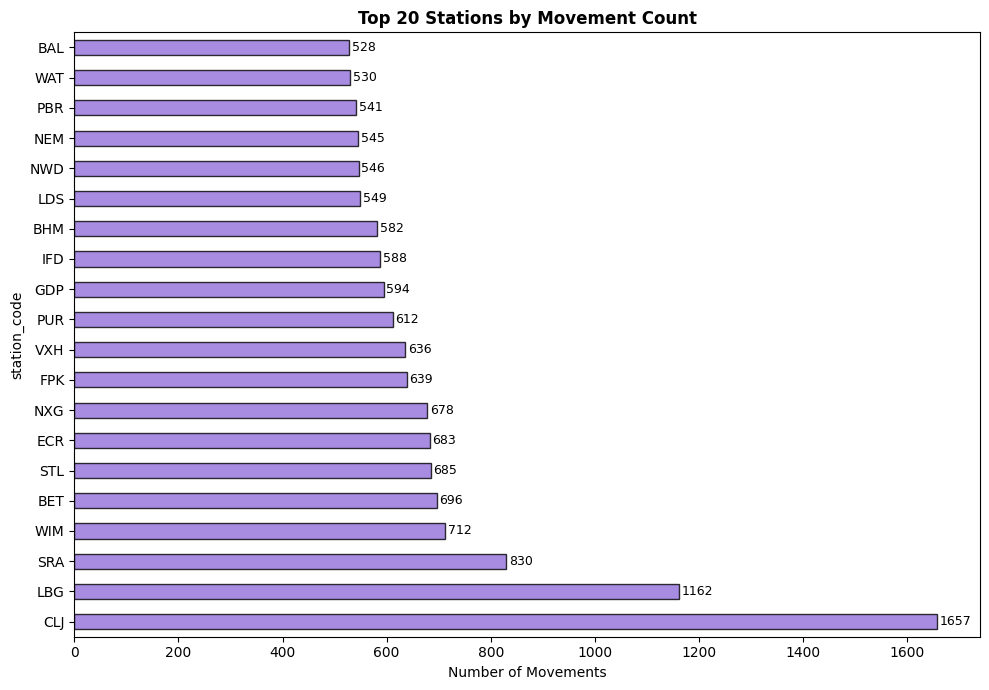

In [42]:
if "station_code" in clean_df.columns:
    matched = clean_df["station_code"].notna() & (clean_df["station_code"] != "")
    print(f"Total movements:           {len(clean_df):,}")
    print(f"With station code matched: {matched.sum():,} ({matched.mean()*100:.1f}%)")
    print(f"Without station code:      {(~matched).sum():,} ({(~matched).mean()*100:.1f}%)")

    top_stations = clean_df[matched]["station_code"].value_counts().head(20)
    plt.figure(figsize=(10, 7))
    top_stations.plot(kind="barh", color="mediumpurple", edgecolor="black", alpha=0.8)
    plt.xlabel("Number of Movements")
    plt.title("Top 20 Stations by Movement Count", fontweight="bold")
    for i, v in enumerate(top_stations.values):
        plt.text(v + 5, i, str(v), va="center", fontsize=9)
    plt.tight_layout()
    plt.savefig("figures/eda_03/top_stations_movements.png", dpi=200, bbox_inches="tight")
    plt.show()

## Operational Flags

=== is_delayed ===
is_delayed
0    123997
1     88887
  True rate: 41.8%

=== delay_monitoring_point ===
delay_monitoring_point
True     110592
False    102292
  True rate: 51.9%

=== train_terminated ===
train_terminated
False    203135
True       9749
  True rate: 4.6%



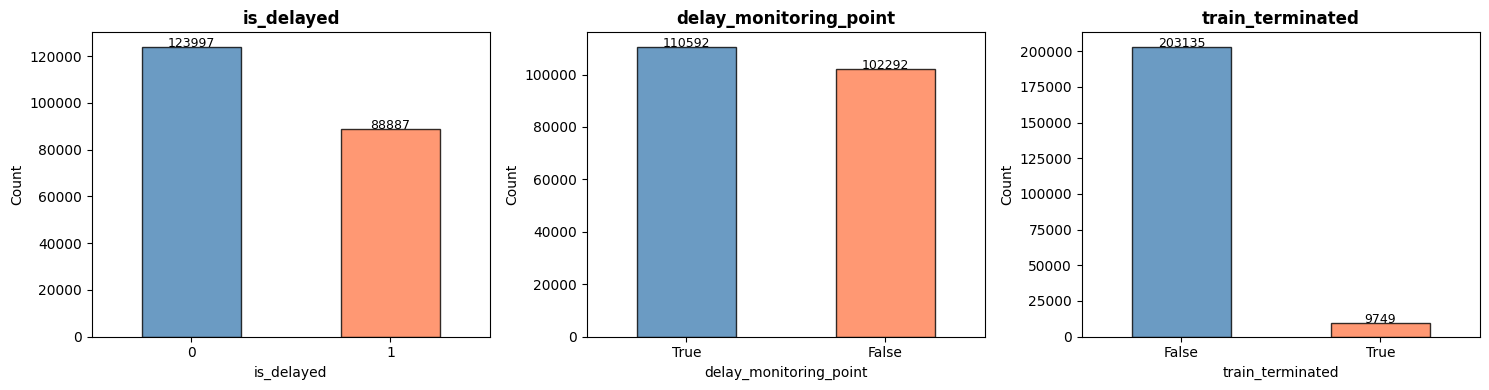

In [43]:
flag_cols = [c for c in ["is_delayed", "delay_monitoring_point", "train_terminated"]
             if c in clean_df.columns]

for col in flag_cols:
    vc = clean_df[col].value_counts(dropna=False)
    pct_true = clean_df[col].eq(True).sum() / len(clean_df) * 100
    print(f"=== {col} ===")
    print(vc.to_string())
    print(f"  True rate: {pct_true:.1f}%\n")

if flag_cols:
    fig, axes = plt.subplots(1, len(flag_cols), figsize=(5 * len(flag_cols), 4))
    if len(flag_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, flag_cols):
        vc = clean_df[col].value_counts(dropna=False)
        vc.plot(kind="bar", ax=ax, color=["steelblue", "coral"],
                edgecolor="black", alpha=0.8)
        ax.set_title(col, fontweight="bold")
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=0)
        for i, v in enumerate(vc.values):
            ax.text(i, v + 5, str(v), ha="center", fontsize=9)
    plt.tight_layout()
    plt.savefig("figures/eda_03/operational_flags.png", dpi=200, bbox_inches="tight")
    plt.show()

## Direction and Data Source

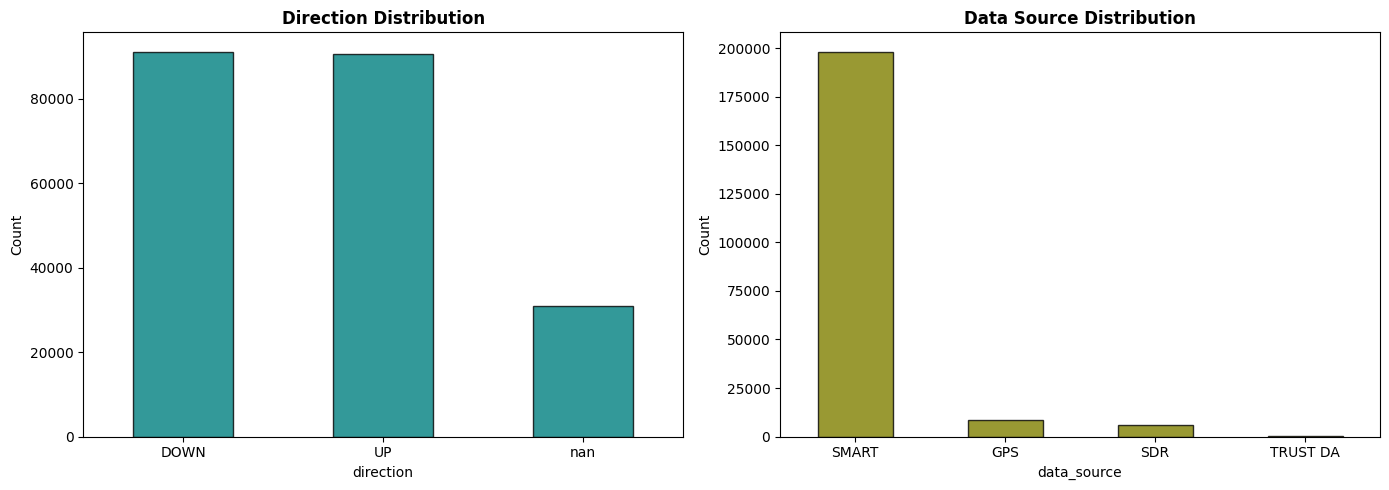

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if "direction" in clean_df.columns:
    dir_counts = clean_df["direction"].value_counts(dropna=False)
    dir_counts.plot(kind="bar", ax=axes[0], color="teal",
                    edgecolor="black", alpha=0.8)
    axes[0].set_title("Direction Distribution", fontweight="bold")
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis="x", rotation=0)

if "data_source" in clean_df.columns:
    ds_counts = clean_df["data_source"].value_counts(dropna=False)
    ds_counts.plot(kind="bar", ax=axes[1], color="olive",
                   edgecolor="black", alpha=0.8)
    axes[1].set_title("Data Source Distribution", fontweight="bold")
    axes[1].set_ylabel("Count")
    axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("figures/eda_03/direction_datasource.png", dpi=200, bbox_inches="tight")
plt.show()

## Aggregate to Station-Day (All Movements)

In [45]:
def aggregate_station_day(df, group_cols=["station_name", "loc_stanox", "planned_date"]):
    agg = (
        df
        .dropna(subset=["station_name"])
        .groupby(group_cols, dropna=False)
        .agg(
            train_movements               = ("planned_timestamp",          "count"),
            mean_delay_minutes            = ("delay_minutes",              "mean"),
            median_delay_minutes          = ("delay_minutes",              "median"),
            late_movements                = ("is_late",                    "sum"),
            mean_late_minutes             = ("late_minutes",               "mean"),
            max_late_minutes              = ("late_minutes",               "max"),
            early_movements               = ("is_early",                   "sum"),
            mean_early_minutes            = ("early_minutes",              "mean"),
            delayed_movements_5min        = ("is_delayed_5min",            "sum"),
            severe_delay_movements_15min  = ("is_severely_delayed_15min",  "sum"),
        )
        .reset_index()
    )
    agg["late_share"]               = agg["late_movements"]               / agg["train_movements"]
    agg["early_share"]              = agg["early_movements"]               / agg["train_movements"]
    agg["delayed_share_5min"]       = agg["delayed_movements_5min"]        / agg["train_movements"]
    agg["severe_delay_share_15min"] = agg["severe_delay_movements_15min"]  / agg["train_movements"]
    agg = agg.rename(columns={"loc_stanox": "stanox"})
    agg["stanox"] = agg["stanox"].apply(
        lambda x: str(int(x)) if pd.notna(x) else None
    )
    return agg

# Full station-day aggregation — all movements
train_station_day = aggregate_station_day(clean_df)

display(train_station_day.head(3))
print(f"Station-day rows: {len(train_station_day):,}")
print(f"Unique stations:  {train_station_day['station_name'].nunique():,}")

,station_name,stanox,planned_date,train_movements,mean_delay_minutes,median_delay_minutes,late_movements,mean_late_minutes,max_late_minutes,early_movements,mean_early_minutes,delayed_movements_5min,severe_delay_movements_15min,late_share,early_share,delayed_share_5min,severe_delay_share_15min
0,Abbey Wood,88601,2026-04-10,15,0.566667,-0.50,5,1.133333,12.0,9,0.566667,1,0,0.333333,0.60,0.066667,0.0
1,Abbey Wood,88601,2026-04-11,2,-0.750000,-0.75,0,0.000000,0.0,2,0.750000,0,0,0.000000,1.00,0.000000,0.0
2,Abbey Wood,88601,2026-04-12,4,1.000000,0.50,3,1.125000,3.5,1,0.125000,0,0,0.750000,0.25,0.000000,0.0


Station-day rows: 33,941
Unique stations:  2,506


In [46]:
# Full cleaned movements — used by eda_05_01 for spatial join and closure tagging
clean_df.to_parquet(
    "./data/processed/train_moments_clean.parquet", index=False
)
print(f"Saved: train_moments_clean.parquet        — {len(clean_df):,} rows")

# Station-day aggregation — primary input to eda_05_01
train_station_day.to_parquet(
    "./data/processed/train_station_day.parquet", index=False
)
print(f"Saved: train_station_day.parquet          — {len(train_station_day):,} rows")

Saved: train_moments_clean.parquet        — 212,884 rows
Saved: train_station_day.parquet          — 33,941 rows
